# 02 - Recession Forecasting Model (Decision Tree / Random Forest / XGBoost)

Runs the full pipeline for the **recession** target end-to-end by calling `src.pipeline.run_target('recession', cfg)` -- the exact same function used to generate everything under `results/` and `data/predictions/`. Re-running this notebook regenerates those files from scratch (deterministic given the fixed `random_state`).

Pipeline: cleaned FRED-MD panel -> engineered features -> label -> horizon alignment -> `TimeSeriesSplit` hyperparameter search (imbalance-aware) -> rolling-window walk-forward OOS backtest -> metrics / confusion matrices / XGBoost feature attribution.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from pipeline import load_config, run_target

cfg = load_config()

## Run the pipeline

This performs the CV hyperparameter search AND the full rolling-window walk-forward backtest for Decision Tree, Random Forest, and XGBoost. It can take several minutes.

In [2]:
result = run_target('recession', cfg, save_outputs=True)
result['metrics_df'].round(4)

2026-09-06 07:46:04,606 INFO ================================================================================


2026-09-06 07:46:04,607 INFO RUNNING PIPELINE for target=recession


2026-09-06 07:46:04,608 INFO ================================================================================


2026-09-06 07:46:04,650 INFO remove_null_rows(max_null=6): dropped 1071/1869 rows (date range kept: 1960-01-01 to 2026-07-01)


2026-09-06 07:46:04,652 INFO remove_null_features(max_null=10): dropped 7/110 columns: ['CLAIMSx', 'CMRMTSPLx', 'AMBSL', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx']


...

2026-09-06 07:46:39,900 INFO Rolling backtest: model=DT, 625 OOS steps, rolling_window=150, OOS starts 1974-06-01


2026-09-06 07:47:08,774 INFO Rolling backtest: model=RF, 625 OOS steps, rolling_window=150, OOS starts 1974-06-01


2026-09-06 07:48:52,522 INFO Rolling backtest: model=XGB, 625 OOS steps, rolling_window=150, OOS starts 1974-06-01


2026-09-06 08:09:06,625 INFO Rolling-OOS metrics for target=recession:
                       DT      RF     XGB
Accuracy           0.9424  0.9552  0.9680
Balanced Accuracy  0.8257  0.9297  0.9175
Precision          0.7667  0.7439  0.8529
Recall             0.6765  0.8971  0.8529
F1                 0.7188  0.8133  0.8529
MCC                0.6885  0.7926  0.8350
ROC-AUC            0.8256  0.9699  0.9772


,DT,RF,XGB
Accuracy,0.9424,0.9552,0.9680
Balanced Accuracy,0.8257,0.9297,0.9175
Precision,0.7667,0.7439,0.8529
Recall,0.6765,0.8971,0.8529
F1,0.7188,0.8133,0.8529
MCC,0.6885,0.7926,0.8350
ROC-AUC,0.8256,0.9699,0.9772


## Best hyperparameters selected (TimeSeriesSplit CV, imbalance-aware)

In [3]:
pd.DataFrame(result['best_params'])

,DT,RF,XGB
max_depth,3.0,3.0,5.00
min_samples_split,2.0,NaN,NaN
min_samples_leaf,1.0,10.0,NaN
n_estimators,NaN,100.0,400.00
learning_rate,NaN,NaN,0.05


## Rolling-OOS confusion matrices

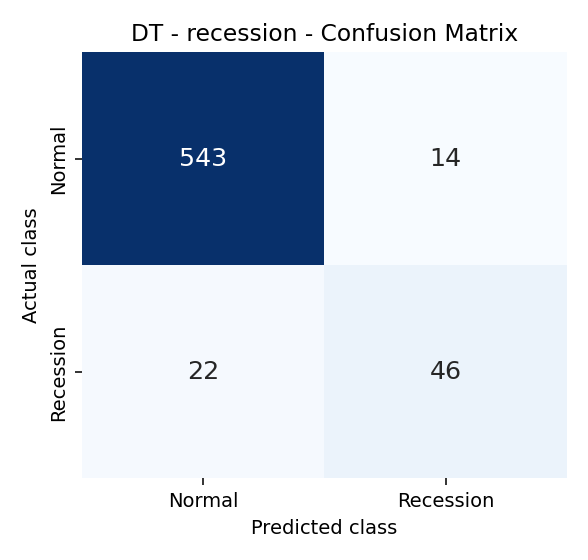

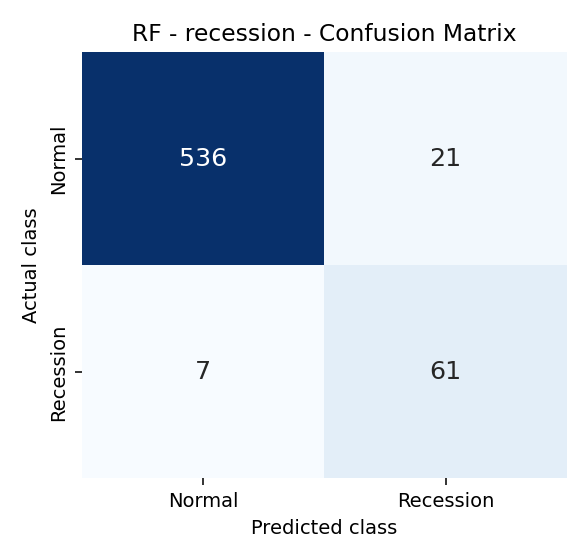

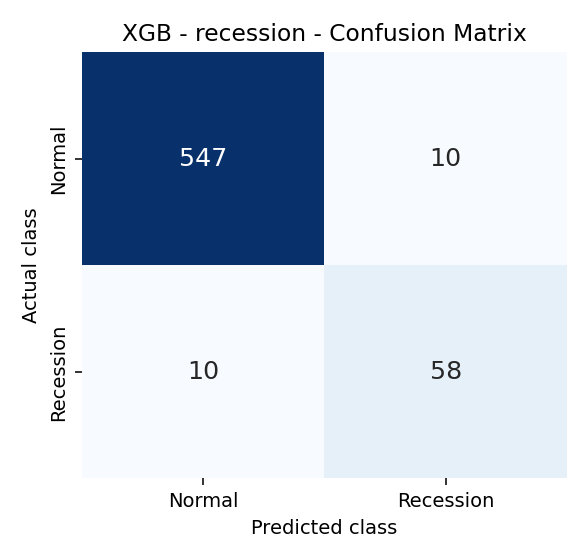

In [4]:
for model in ['DT','RF','XGB']:
    display(Image(filename=f'../results/confusion_matrices/recession_{model}_cm.png'))

## Predicted probability vs actual regime, across the full rolling OOS backtest

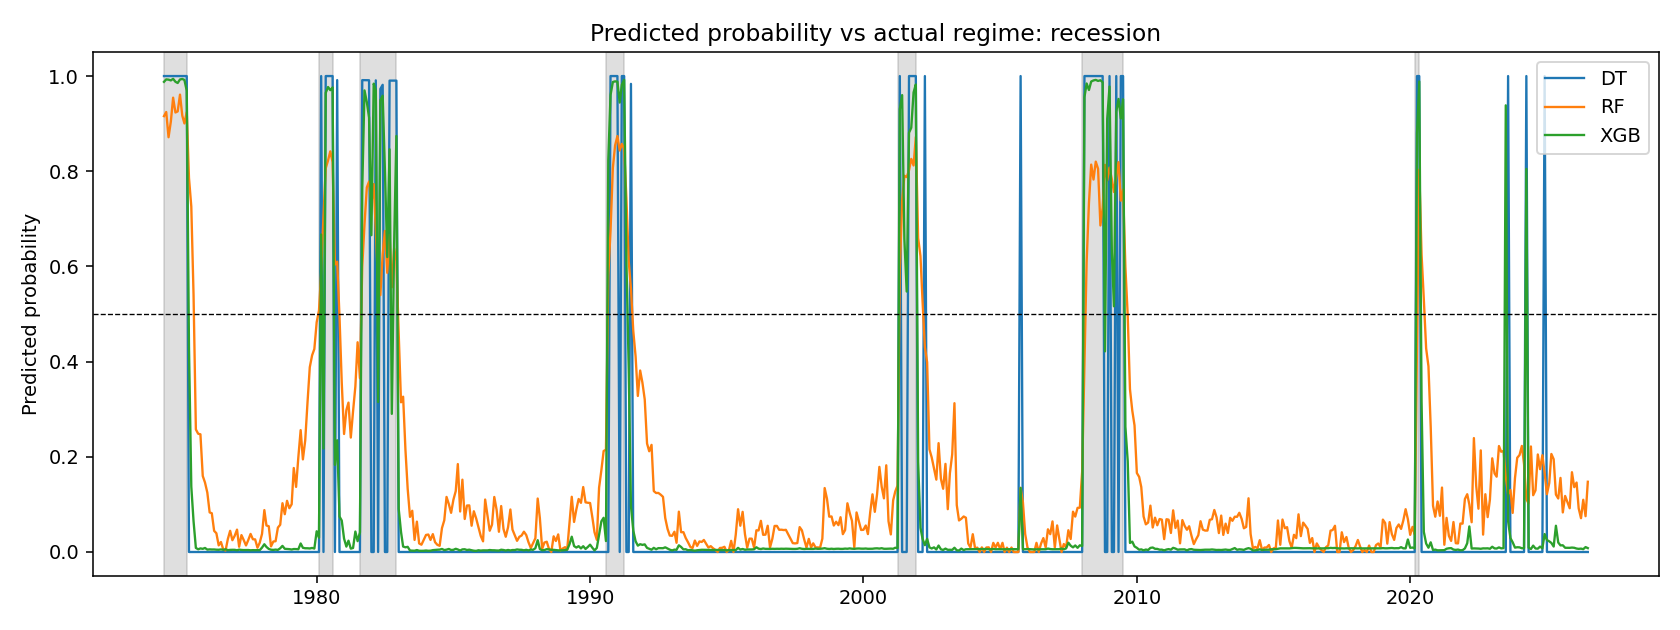

In [5]:
display(Image(filename='../results/figures/recession_regime_probabilities.png'))

## XGBoost feature attribution

Aggregated across every rolling-window refit: top individual features, rolled up by macro group, and rolled up by engineered-feature type (lag / spread / momentum / rolling-stat / drawdown / volatility).

In [6]:
fi = pd.read_csv('../results/feature_importance_recession.csv')
fi.head(15)

,Feature,Importance,source_series,group,feat_type
0,TB3SMFFM__lag6,0.020162,TB3SMFFM,Interest and Exchange Rates,lag
1,TB6SMFFM__rollmean12,0.019529,TB6SMFFM,Interest and Exchange Rates,rolling_stat
2,T1YFFM__lag6,0.019170,T1YFFM,Interest and Exchange Rates,lag
3,CPIMEDSL__mom6,0.016952,CPIMEDSL,Prices,momentum
4,FEDFUNDS__rollmean6,0.016324,FEDFUNDS,Interest and Exchange Rates,rolling_stat
5,CUSR0000SAS__mom12,0.015463,CUSR0000SAS,Prices,momentum
6,TB6SMFFM__lag6,0.014959,TB6SMFFM,Interest and Exchange Rates,lag
7,CPIMEDSL__mom12,0.013484,CPIMEDSL,Prices,momentum
8,TB3MS__rollstd12,0.013449,TB3MS,Interest and Exchange Rates,rolling_stat
9,T1YFFM__rollmean24,0.012512,T1YFFM,Interest and Exchange Rates,rolling_stat


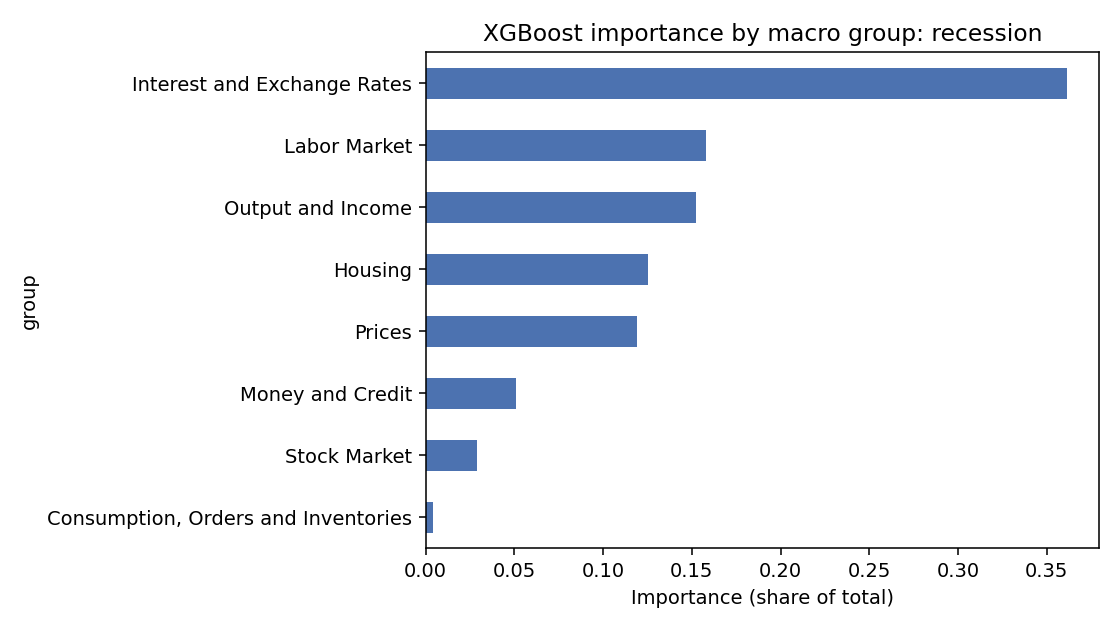

In [7]:
display(Image(filename='../results/figures/recession_importance_by_group.png'))

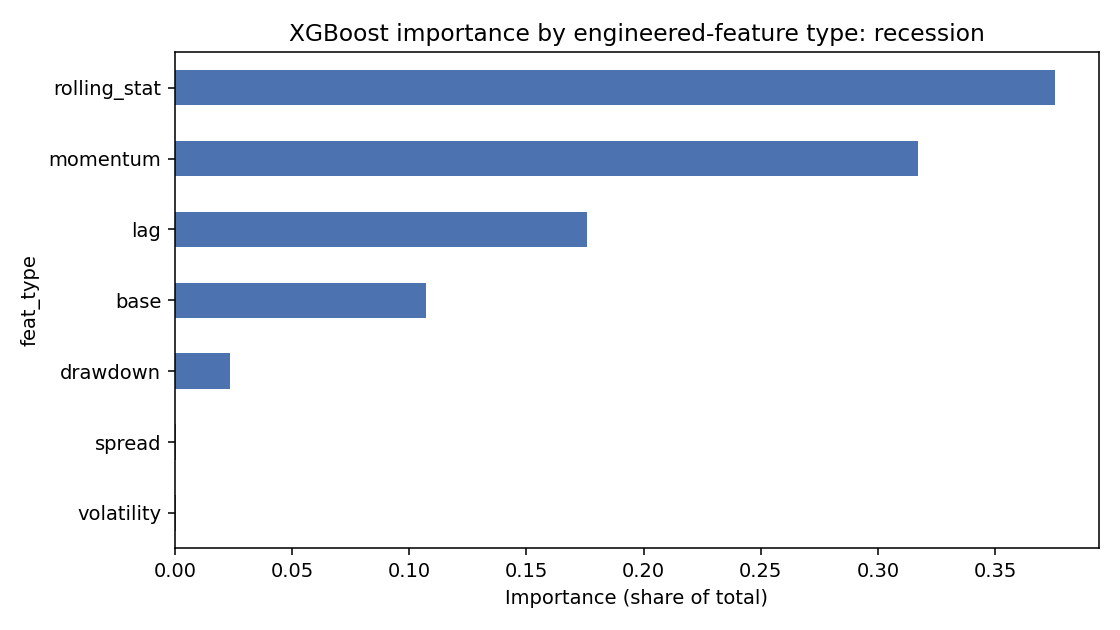

In [8]:
display(Image(filename='../results/figures/recession_importance_by_type.png'))